In [ ]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.factory import make_pre_post_processors
from lerobot.policies.act.modeling_act import ACTPolicy
import numpy as np
import cv2
import torch

class BehaviorCloningPolicyWrapper:
    def __init__(self, policy_ckpt, dataset_path, repo_id, policy_type='act'):
        self.policy_type=policy_type
        self.dataset_path = dataset_path
        self.policy_ckpt = policy_ckpt
        self.dataset = LeRobotDataset(repo_id = repo_id, root = dataset_path, video_backend='pyav')
        self.policy = ACTPolicy.from_pretrained(policy_ckpt)
        self.preprocessor, self.postprocessor = make_pre_post_processors(
                                                    policy_cfg=self.policy,
                                                    pretrained_path=policy_ckpt,
                                                    dataset_stats=self.dataset.meta.stats,
                                                    preprocessor_overrides={"device_processor": {"device": str(self.policy.config.device)}},
                                                )
        self.policy = self.policy.eval()
        
    def reset(self):
        self.policy.reset()
        self.preprocessor.reset()
        self.postprocessor.reset()

    def getCommand(self, image):
        with torch.no_grad():
            img = cv2.resize(image, (64, 64))
            img = torch.from_numpy(image.astype(np.float32)/255.).permute(2,0,1).unsqueeze(0)
            obs = {
            'observation.state':torch.zeros(1, 3).cuda(),
            'observation.image': img,
            }
            obs_processed = self.preprocessor(obs)
            action = self.policy.select_action(obs_processed)
            action = self.postprocessor(action)
            return action.cpu().numpy()

In [ ]:
dataset_root = "/home/rooholla/projects/ego-cube-go2/ego-pushcube"
repo_id = "ego-pushcube"
policy_ckpt = "/home/rooholla/projects/ego-cube-go2/policy/lowres/act/checkpoints/last/pretrained_model"
policy = BehaviorCloningPolicyWrapper(policy_ckpt, dataset_root, repo_id)

Loading weights from local directory


In [20]:
img = np.random.randn(256, 256, 3)
policy.getCommand(img)

array([[-0.22382626,  0.9282253 ,  0.08758171]], dtype=float32)

In [8]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset
dataset = LeRobotDataset(repo_id = "ego-pushcube", root = "/home/rooholla/projects/ego-cube-go2/ego-pushcube", video_backend='pyav')

In [10]:
dataset[0]['observation.image'].shape

torch.Size([3, 64, 64])

In [13]:
import pyrealsense2 as rs
import threading
import cv2
import numpy as np
class RealSenseCamera:
    """
    A class for interacting with a RealSense cameras.

    Args:
        callback_fn (callable, optional): The callback function to process frames.
        camera_serial_no (str, optional): The serial number of the camera.
        VGA (bool): Set to True for VGA resolution, False for HD resolution.
        color_fps (int): Frame rate for color stream (frames per second).
        depth_fps (int): Frame rate for depth stream (frames per second).
        enable_imu (bool): Enable or disable IMU stream.
        enable_depth (bool): Enable or disable depth stream.
        enable_color (bool): Enable or disable color stream.
        enable_ir (bool): Enable or disable infrared stream.
        emitter_enabled (bool): Enable or disable emitter for the depth sensor.
        align_to_color (bool): Align depth and IR streams to color.

    Attributes:
        callback_fn (callable, optional): The callback function to process frames.
        camera_serial_no (str): The serial number of the camera.
        VGA (bool): True if VGA resolution, False if HD resolution.
        color_fps (int): Frame rate for color stream (frames per second).
        depth_fps (int): Frame rate for depth stream (frames per second).
        enable_imu (bool): True if IMU stream is enabled.
        enable_depth (bool): True if depth stream is enabled.
        enable_color (bool): True if color stream is enabled.
        enable_ir (bool): True if infrared stream is enabled.
        emitter_enabled (bool): True if emitter is enabled for the depth sensor.
        align_to_color (bool): True if depth and IR streams are aligned to color.
    """
    def __init__(self, callback_fn = None, 
                       camera_serial_no=None, 
                       VGA = True,
                       color_fps=60,
                       depth_fps=90, 
                       enable_imu=False,
                       enable_depth=True, 
                       enable_color=True, 
                       enable_ir=True, 
                       emitter_enabled=True,
                       align_to_color = False):
        
        self.callback_fn = callback_fn
        self.camera_serial_no = camera_serial_no
        self.VGA = VGA
        self.color_fps = color_fps
        self.depth_fps = depth_fps
        self.enable_depth = enable_depth
        self.enable_color = enable_color
        self.align_to_color = align_to_color
        self.enable_ir = enable_ir
        self.pipeline = rs.pipeline()
        self.config = rs.config()
        self.enable_imu = enable_imu
        if self.camera_serial_no is None:
            # Get device product line for setting a supporting resolution
            pipeline_wrapper = rs.pipeline_wrapper(self.pipeline)
            pipeline_profile = self.config.resolve(pipeline_wrapper)
            device = pipeline_profile.get_device()
            serial_no = str(device.get_info(rs.camera_info.serial_number))
            self.camera_serial_no = serial_no
        
        # Enable the streams for the connected device with the requested serial number
        print('Enabling streams for camera: ', self.camera_serial_no)
        self.config.enable_device(self.camera_serial_no)
        if VGA:
            img_size = (640, 480)
            if color_fps > 60:
                self.color_fps = 60
                print('Warning: VGA color fps cannot be higher than 60')
            if depth_fps > 90:
                self.depth_fps = 90
                print('Warning: VGA depth/infrared fps cannot be higher than 90')
        else:
            img_size = (1280, 720)
            if color_fps > 30:
                self.color_fps = 30
                print('Warning: HD color fps cannot be higher than 30')
            if depth_fps > 30:
                self.depth_fps = 30
                print('Warning: HD depth/infrared fps cannot be higher than 30')
        
        if enable_depth:
            self.config.enable_stream(rs.stream.depth, img_size[0], img_size[1], rs.format.z16, self.depth_fps)
        if enable_color:
            self.config.enable_stream(rs.stream.color, img_size[0], img_size[1], rs.format.bgr8, self.color_fps)
        if enable_ir:
            self.config.enable_stream(rs.stream.infrared, 1, img_size[0], img_size[1], rs.format.y8, self.depth_fps)
            self.config.enable_stream(rs.stream.infrared, 2, img_size[0], img_size[1], rs.format.y8, self.depth_fps)
        if self.enable_imu:
            self.config.enable_stream(rs.stream.accel)
            self.config.enable_stream(rs.stream.gyro)

        self.profile = self.pipeline.start(self.config)
        self.depth_sensor = self.profile.get_device().first_depth_sensor()
        if emitter_enabled:
            self.depth_sensor.set_option(rs.option.emitter_enabled, 1)
        else:
            self.depth_sensor.set_option(rs.option.emitter_enabled, 0)
        
        # Start the thread for grabbing frames
        self._stop_event = threading.Event()
        self._thread = threading.Thread(target=self._run_grab_frames)
        self._thread.start()
        #Get stream profiles
        self.depth_profile = self.profile.get_stream(rs.stream.depth).as_video_stream_profile()
        self.color_profile = self.profile.get_stream(rs.stream.color).as_video_stream_profile()
        self.ir1_profile = self.profile.get_stream(rs.stream.infrared,1).as_video_stream_profile()
        self.ir2_profile = self.profile.get_stream(rs.stream.infrared,2).as_video_stream_profile()
        #Depth frame aligner
        self.align = rs.align(rs.stream.color)
        self.color_frame = None
        self.depth_frame = None

    def _run_grab_frames(self):
        """
        Private method to continuously grab frames in a separate thread.
        """
        while not self._stop_event.is_set():
            self.grab_frames()
            if self.callback_fn is not None:
                self.callback_fn(self.color_frame, self.depth_frame, self.ir1_frame, self.ir2_frame)

    def close(self):
        """
        Closes the RealSenseCamera object, stopping the frame grabbing thread and the pipeline.
        """
        # Stop the thread
        self._stop_event.set()
        self._thread.join()
        # Stop the pipeline
        self.pipeline.stop()

    def grab_frames(self):
        """
        Grabs frames from the RealSense camera and stores them in instance variables.
        """
        frames = self.pipeline.wait_for_frames()
        if self.align_to_color:
            frames = self.align.process(frames)
        if frames is None:
            print('Warning: failed to grab frames')
            self.close()
            
        if self.enable_depth:
            self.depth_frame = np.asanyarray(frames.get_depth_frame().get_data())
        else:
            self.depth_frame = None
        if self.enable_color:
            self.color_frame = np.asanyarray(frames.get_color_frame().get_data())
        else:
            self.color_frame = None
        if self.enable_ir:
            self.ir1_frame =   np.asanyarray(frames.get_infrared_frame(1).get_data())
            self.ir2_frame =   np.asanyarray(frames.get_infrared_frame(2).get_data())
        else:
            self.ir1_frame = None
            self.ir2_frame = None
        
        if self.enable_imu:
            self.accel_frame = frames.first_or_default(rs.stream.accel)
            self.gyro_frame = frames.first_or_default(rs.stream.gyro)
            # Optionally convert the IMU frames to arrays as needed, e.g., np.asanyarray(...)
        else:
            self.accel_frame = None
            self.gyro_frame = None

    def getIntrinsics(self):
        """
        Gets the intrinsic parameters of cameras.

        Returns:
            dict: A dictionary containing intrinsics for RGB, IR1, IR2, and Depth streams.
        """
        rgb_intr = self.color_profile.get_intrinsics()
        ir1_intr = self.ir1_profile.get_intrinsics()
        ir2_intr = self.ir2_profile.get_intrinsics()
        depth_intr = self.depth_profile.get_intrinsics()

        ir1_intr = self.parseIntr(ir1_intr)
        ir2_intr = self.parseIntr(ir2_intr)
        depth_intr = self.parseIntr(depth_intr)
        rgb_intr = self.parseIntr(rgb_intr)

        return {'RGB':rgb_intr,
                'IR1':ir1_intr,
                'IR2':ir2_intr,
                'Depth':depth_intr}
    
    def getExtrinsics(self):
        """
        Gets the extrinsics between different camera streams.

        Returns:
            dict: A dictionary containing pose of all streams with respect to depth/infrared1.
        """
        ir1_T_ir2 = self.ir2_profile.get_extrinsics_to(self.ir1_profile) # Pose of ir2 with respect to ir1
        ir1_T_rgb = self.color_profile.get_extrinsics_to(self.ir1_profile) # Pose of rgb with respect to ir1
        ir1_T_ir2 = self.toPose(ir1_T_ir2)
        ir1_T_rgb = self.toPose(ir1_T_rgb)
        return {'ir1_T_ir2':ir1_T_ir2,
                'ir1_T_rgb':ir1_T_rgb}

    def toPose(self,e):
        """
        Converts a RealSense extrinsics object to a 4x4 transformation matrix.

        Args:
            e (rs.extrinsics): The extrinsics object.

        Returns:
            numpy.ndarray: A 4x4 transformation matrix representing the extrinsics.
        """
        R = np.array(e.rotation).reshape(3,3)
        t = np.array(e.translation).reshape(3,1)
        return np.vstack([np.hstack([R,t]), np.array([0,0,0,1])])

    def parseIntr(self,intr):
        """
        Parses intrinsics data into a dictionary for easier access.

        Args:
            intr (rs.intrinsics): The intrinsics object.

        Returns:
            dict: A dictionary containing intrinsics data.
        """
        h,w = intr.height, intr.width
        fx, fy = intr.fx,intr.fy
        cx,cy = intr.ppx,intr.ppy
        dist = np.array(intr.coeffs)
        K = np.array([fx, 0, cx,
                    0,fy, cy,
                    0, 0, 1]).reshape(3,3)
        return {'size':(w,h),
                'fx':fx,
                'fy':fy,
                'cx':cx,
                'cy':cy,
                'K':K,
                'D':dist}   

In [4]:
sample = dataset[0]

In [7]:
# sample['observation.images.camera_0'].shape
sample['observation.image'].shape


torch.Size([3, 64, 64])

In [8]:
sample['observation.state']

tensor([0., 0., 0.])

In [14]:
camera = RealSenseCamera()


Enabling streams for camera:  231622302407


In [229]:
import zerorpc
import numpy as np
class NYUFingerHardwareV2:
    def __init__(self, 
                 robot_ip='192.168.123.10',
                 dt=0.01):
        self.robot = zerorpc.Client()
        self.robot.connect(f"tcp://{robot_ip}:4242")
        self.q_raw = np.zeros(3)
        self.q_dir = np.array([-1, 1, -1])
        self.dt = dt
        self.running = True
        self.alpha = 0.9
        self.tau_alpha = 0.9
        self.tau_f = np.zeros(3) # filtered torque
        self.dq_f = np.zeros(3) # filtered velocity
        
        # Reset the relative encoder value
        state = self.robot.getJointStates()
        self.q0_rel = np.array([state[f'joint_{i+1}']['q'] for i in range(3)])
        # Get the current absolute joint angles from the absolute joint encoders
        self.q_offset = self.getAbsoluteJointAngles()

    def getAbsoluteJointAngles(self):
        abs_state = self.robot.getAbsJointStates()
        q_abs_offset = np.array([10.4, 0.88, 3.84])
        q_abs = np.array([s['q_abs'] for s in abs_state.values()]) - q_abs_offset
        return q_abs * np.array([0.5, 0.91, 1.]) * np.array([-1, -1, -1])
    
    def getAbsoluteJointAnglesRaw(self):
        abs_state = self.robot.getAbsJointStates()
        q_abs = np.array([s['q_abs'] for s in abs_state.values()])
        return q_abs

    def get_state(self):
        state = self.robot.getJointStates()
        q = np.array([state[f'joint_{i+1}']['q'] for i in range(3)])
        dq = np.array([state[f'joint_{i+1}']['dq'] for i in range(3)])
        tau = np.array([state[f'joint_{i+1}']['tau'] for i in range(3)])
        
        self.q_raw = q.copy()
        q = (q - self.q0_rel) * self.q_dir + self.q_offset
        dq = dq * self.q_dir
        
        # Filter velocity
        self.dq_f = self.alpha * self.dq_f + (1 - self.alpha) * dq
        self.tau_f = self.tau_alpha*self.tau_f + (1-self.tau_alpha)*tau
        
        # Return q, filtered velocity, and torque
        return q, self.dq_f, self.tau_f

    def send_joint_cmd(self, q, dq, joint_torques):
        tauff = joint_torques * self.q_dir
        qdes = (q - self.q_offset) * self.q_dir + self.q0_rel
        dqdes = dq * self.q_dir
        command = {f'joint_{i+1}': {'q': qdes[i], 'dq': dqdes[i], 'tau': tauff[i]} for i in range(3)}
        self.robot.setJointCommand(command)

    def reset_sensors(self, q0=np.zeros(3)):
        pass

# --- Setup ---
robot = NYUFingerHardwareV2()

In [14]:
from lerobot.policies.act.modeling_act import ACTPolicy
# policy = ACTPolicy.from_pretrained("/home/rooholla/projects/lerobot/outputs/train/place_cubes-v2-act-relative-continued/checkpoints/last/pretrained_model/")
policy = ACTPolicy.from_pretrained("/home/rooholla/projects/ego-cube-go2/policy/lowres/act/checkpoints/last/pretrained_model")
policy.config.input_features


Loading weights from local directory


{'observation.image': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(64, 64, 3))}

In [11]:
import torch
q = torch.from_numpy(robot.get_state()[0])

NameError: name 'robot' is not defined

In [ ]:
import torch
img = torch.from_numpy(cv2.cvtColor(camera.color_frame, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0).permute(2,0,1).unsqueeze(0)

In [244]:
robot.get_state()

(array([-0.01839776, -0.73140695,  0.12160723]),
 array([0.00183557, 0.00139101, 0.00029319]),
 array([-0.0273096 , -0.06031524, -0.023859  ]))

In [3]:
from lerobot.policies.factory import make_pre_post_processors
preprocessor, postprocessor = make_pre_post_processors(
        policy_cfg=policy,
        pretrained_path="/home/rooholla/projects/lerobot/outputs/train/place_cubes-act-relative-no-state/checkpoints/last/pretrained_model",
        dataset_stats=dataset.meta.stats,
        # The inference device is automatically set to match the detected hardware, overriding any previous device settings from training to ensure compatibility.
        preprocessor_overrides={"device_processor": {"device": str(policy.config.device)}},
    )

In [15]:
from lerobot.policies.factory import make_pre_post_processors
preprocessor, postprocessor = make_pre_post_processors(
        policy_cfg=policy,
        pretrained_path="/home/rooholla/projects/ego-cube-go2/policy/lowres/act/checkpoints/last/pretrained_model",
        dataset_stats=dataset.meta.stats,
        # The inference device is automatically set to match the detected hardware, overriding any previous device settings from training to ensure compatibility.
        preprocessor_overrides={"device_processor": {"device": str(policy.config.device)}},
    )

In [ ]:
q.to(torch.float32).shape

In [ ]:
dataset[offset+i]['observation.state'][None].shape

In [8]:
policy.config.input_features

{'observation.images.camera_0': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 480, 640))}

In [4]:
import numpy as np
policy.reset()
from tqdm import tqdm
offset = 2500





import torch

actions = []
states = []
actions_gt = []
imgs=[]
policy.reset()
preprocessor.reset()
postprocessor.reset()
policy.eval()
for i in tqdm(range(128)):
    obs = {
    'observation.state':torch.zeros_like(dataset[offset+i]['observation.state'][None]).cuda(),
    'observation.images.camera_0':dataset[offset+i]['observation.images.camera_0'][None].cuda(),
    }
    obs_processed = preprocessor(obs)
    action = policy.select_action(obs_processed)
    action = postprocessor(action)
    actions.append(action.cpu().clone())
    actions_gt.append(dataset[offset+i]['action'])
    
    
    imgs.append((dataset[offset+i]['observation.images.camera_0'].cpu().permute(1,2,0).numpy()*255).astype(np.uint8))
    # imgs.append((img[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8))
    
    
    states.append(dataset[offset+i]['observation.state'].cpu())
actions = torch.stack(actions).squeeze().cpu().numpy()
actions_gt = torch.stack(actions_gt)
states = torch.stack(states).squeeze().cpu().numpy()

100%|██████████| 128/128 [00:06<00:00, 20.45it/s]


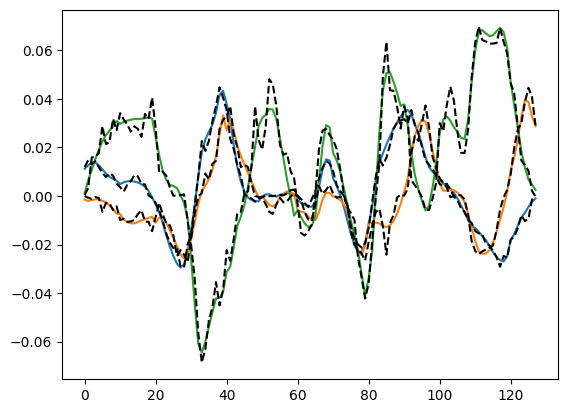

In [5]:

import matplotlib.pyplot as plt
# plt.plot(np.cumsum(actions[:], axis=0))
# plt.plot(np.cumsum(actions_gt[:], axis=0), 'k--')
# plt.plot(states[:,0])
plt.plot(actions[:])
plt.plot(actions_gt[:], 'k--')


In [18]:
import numpy as np
policy.reset()
from tqdm import tqdm
offset = 2500





import torch

actions = []
states = []
actions_gt = []
imgs=[]
policy.reset()
preprocessor.reset()
postprocessor.reset()
policy.eval()
for i in tqdm(range(256)):
    obs = {
    'observation.state':torch.zeros_like(dataset[offset+i]['observation.state'][None]).cuda(),
    'observation.image':dataset[offset+i]['observation.image'][None].cuda(),
    }
    obs_processed = preprocessor(obs)
    action = policy.select_action(obs_processed)
    action = postprocessor(action)
    actions.append(action.cpu().clone())
    actions_gt.append(dataset[offset+i]['action'])
    
    
    imgs.append((dataset[offset+i]['observation.image'].cpu().permute(1,2,0).numpy()*255).astype(np.uint8))
    # imgs.append((img[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8))
    
    
    states.append(dataset[offset+i]['observation.state'].cpu())
actions = torch.stack(actions).squeeze().cpu().numpy()
actions_gt = torch.stack(actions_gt)
states = torch.stack(states).squeeze().cpu().numpy()

100%|██████████| 256/256 [00:07<00:00, 32.93it/s]


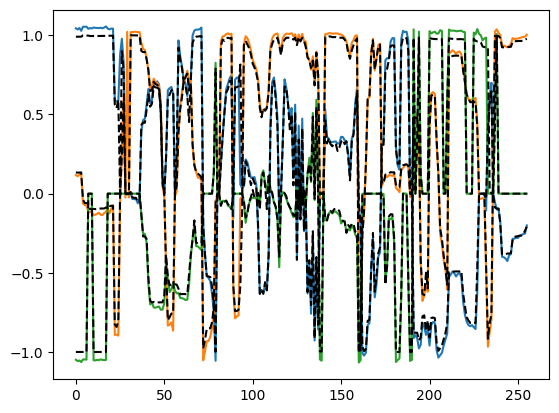

In [19]:

import matplotlib.pyplot as plt
# plt.plot(np.cumsum(actions[:], axis=0))
# plt.plot(np.cumsum(actions_gt[:], axis=0), 'k--')
# plt.plot(states[:,0])
plt.plot(actions[:])
plt.plot(actions_gt[:], 'k--')


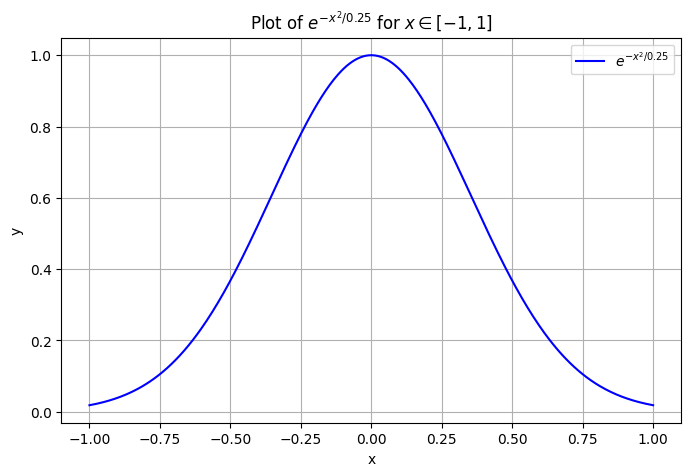

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(-1, 1, 400)

# Calculate y values for the function exp(-x^2/0.25)
y = np.exp(-x**2 / 0.25)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$e^{-x^2/0.25}$', color='blue')
plt.title(r'Plot of $e^{-x^2/0.25}$ for $x \in [-1, 1]$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
cmd = torch.tensor([-0.03870655, -0.95152168,  1.0425692]) 

offset = cmd - actions_gt[0]

cmd-offset -actions_gt[0], offset

(tensor([0., 0., 0.]), tensor([-0.0086, -0.0155,  0.0062]))

In [15]:
import mediapy
mediapy.show_video(imgs, fps=30)

This browser does not support the video tag.


In [17]:

for i in range(5000):
    cv2.imshow('diff', np.abs(cv2.cvtColor(imgs[0], cv2.COLOR_BGR2GRAY).astype(np.float32)-cv2.cvtColor(camera.color_frame, cv2.COLOR_BGR2GRAY).astype(np.float32)).astype(np.uint8))
    cv2.waitKey(10)

cv2.destroyAllWindows()

In [ ]:
from lerobot.policies.factory import make_policy, make_pre_post_processors
from lerobot.policies.pretrained import PreTrainedPolicy
from lerobot.processor import PolicyAction, PolicyProcessorPipeline
from lerobot.utils.constants import ACTION, DONE, OBS_STR, REWARD
from lerobot.utils.import_utils import register_third_party_plugins
from lerobot.utils.io_utils import write_video
from lerobot.utils.random_utils import set_seed
from lerobot.utils.utils import (
    get_safe_torch_device,
    init_logging,
    inside_slurm,
)

In [ ]:
robot.get_state()

In [ ]:
actions_gt[0].numpy()

In [ ]:
robot.send_joint_cmd(actions_gt[0].numpy(), np.zeros(3), np.zeros(3))

In [ ]:
import time
for i in range(actions_gt.shape[0]):
    robot.send_joint_cmd(actions_gt[i].numpy(), np.zeros(3), np.zeros(3))
    time.sleep(0.05)

In [ ]:
actions_gt[0]

In [36]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset
input_dataset_path = "/home/rooholla/projects/nyu-finger/ROB2004/data/cube-to-bag"
output_dataset_path = "/home/rooholla/projects/nyu-finger/ROB2004/data/cube-to-bag-relative"
input_dataset_id = "nyufinger_dataset"
input_dataset = LeRobotDataset(repo_id = input_dataset_id, root = input_dataset_path, video_backend='pyav')

In [39]:
input_dataset.features['observation.state']['shape'] = (6,)
input_dataset.features['observation.state']['name'] = ['q1', 'q2', 'q3', 'tau1', 'tau2', 'tau3']
dataset = LeRobotDataset.create(
                repo_id=input_dataset_id,
                fps=input_dataset.fps,
                root=output_dataset_path,
                robot_type="nyufinger",
                features=input_dataset.features,
                use_videos=True,
                image_writer_threads=8  # Parallel MP4 encoding
            )

In [40]:
from tqdm import tqdm
import torch
import numpy as np
action_prev = input_dataset[0]['action']
episode_index_prev = input_dataset[0]['episode_index']

for dataset_idx in tqdm(range(len(input_dataset))):
    episode_index = input_dataset[dataset_idx]['episode_index']
    if episode_index != episode_index_prev:
        episode_index_prev = episode_index
        dataset.save_episode()
        dataset.clear_episode_buffer()
    sample = input_dataset[dataset_idx]
    action = sample['action']
    relative_action = action - action_prev
    action_prev = action.clone()
    img = (sample['observation.images.camera_0'].permute(1,2,0).numpy()*255.0).astype(np.uint8)
    q = sample['observation.state'].numpy()
    tau = sample['observation.effort'].numpy()
    velocity = sample['observation.velocity'].numpy()
    state = np.concatenate([q, tau], axis=0)
    task = sample['task']
    # Create new sample with relative action
    sample_new = {}
    sample_new['action'] = relative_action
    sample_new['observation.images.camera_0'] = img
    sample_new['observation.state'] = state
    sample_new['observation.velocity'] = velocity
    sample_new['observation.effort'] = tau
    sample_new['task'] = task
    dataset.add_frame(sample_new)

dataset.save_episode()
dataset.consolidate()

  1%|          | 703/62068 [00:13<18:35, 55.01it/s]

Map:   0%|          | 0/707 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 6
Svt[info]: Number of PPCS 161
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF /

Map:   0%|          | 0/541 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 6
Svt[info]: Number of PPCS 161
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF /

...

Map:   0%|          | 0/464 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 6
Svt[info]: Number of PPCS 161
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF /

Map:   0%|          | 0/452 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 6
Svt[info]: Number of PPCS 161
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 20 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF /

AttributeError: 'LeRobotDataset' object has no attribute 'consolidate'

In [41]:
dataset.finalize()